In [3]:
# ============================================================
# BraTS Brain Tumor Segmentation — XGBoost v5 FIXED
# ZERO disk writes except best_threshold_v5.npy (8 bytes)
# Everything — features, model, results — lives in RAM only.
# Tumor ratio : ~9.1%  |  Threshold : 0.6 (fixed)
# ============================================================

import numpy as np
import nibabel as nib
import os
import gc
import glob
import joblib
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import uniform_filter, gaussian_filter, sobel as nd_sobel
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, f1_score,
                              jaccard_score, roc_auc_score)

# ── Reproducibility ────────────────────────────────────────
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────
BASE_DIR  = r"D:\shashwat"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

MODALITIES = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX = 'seg'

# ── Tunable settings ───────────────────────────────────────
TUMOR_BG_RATIO = 46
MAX_TRAIN      = 2_000_000
MAX_VAL        = 1_000_000
N_ESTIMATORS   = 300
MAX_DEPTH      = 8
DEVICE         = 'cpu'

BEST_THRESHOLD      = 0.6    # fixed — no tuning loop
THRESHOLD_SAVE_PATH = os.path.join(MODEL_DIR, "best_threshold_v7.npy")
MODEL_SAVE_PATH     = os.path.join(MODEL_DIR, "xgb_brain_tumor_v7.pkl")


# ==============================================================
# SECTION 1: Core helpers
# ==============================================================

def get_patient_dirs(split_dir):
    return sorted([d for d in Path(split_dir).iterdir() if d.is_dir()])


def load_patient(patient_dir):
    patient_dir = Path(patient_dir)
    pid  = patient_dir.name
    data = {}
    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            raise FileNotFoundError(f"Missing {mod} for {pid}")
        data[mod] = nib.load(matches[0]).get_fdata(dtype=np.float32)
    return pid, data


def get_brain_mask(data):
    mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        mask |= (data[mod] > 0)
    return mask


def zscore_normalize(volume, brain_mask):
    v   = volume.copy()
    roi = v[brain_mask]
    mu, sigma = roi.mean(), roi.std() + 1e-8
    v[brain_mask]  = (roi - mu) / sigma
    v[~brain_mask] = 0.0
    return v


def preprocess_patient(data):
    brain_mask = get_brain_mask(data)
    processed  = {}
    for mod in MODALITIES:
        processed[mod] = zscore_normalize(data[mod], brain_mask)
    processed[SEG_SUFFIX] = data[SEG_SUFFIX]
    return processed, brain_mask


def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)


def extract_features(processed, brain_mask):
    """53 features, brain voxels only. All in RAM."""
    cols = []

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))
        del vol

    for mod in MODALITIES:
        vol = processed[mod].astype(np.float32)
        add(vol.copy())
        add(uniform_filter(vol, size=3))
        add(fast_local_std(vol, size=3))
        add(uniform_filter(vol, size=5))
        add(fast_local_std(vol, size=5))
        add(uniform_filter(vol, size=9))
        add(fast_local_std(vol, size=9))
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(gaussian_filter(vol, sigma=1.0).astype(np.float32))
        add(gaussian_filter(vol, sigma=2.0).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        add((g1 - g2).astype(np.float32))
        del g1, g2, vol
        gc.collect()

    shape = processed[MODALITIES[0]].shape
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); del xx
    add(yy); del yy
    add(zz); del zz
    gc.collect()

    eps = 1e-8
    add(np.clip(processed['t2w'] / (processed['t1c'] + eps), -10, 10).astype(np.float32))
    add(np.clip(processed['t2f'] / (processed['t1n'] + eps), -10, 10).astype(np.float32))
    add((processed['t2f'] - processed['t1c']).astype(np.float32))
    add((processed['t2w'] - processed['t1n']).astype(np.float32))
    add((processed['t1c'] - processed['t1n']).astype(np.float32))
    add((processed['t2f'] - processed['t2w']).astype(np.float32))

    X = np.column_stack(cols).astype(np.float32)
    del cols; gc.collect()

    y = (processed[SEG_SUFFIX][brain_mask] > 0).astype(np.uint8)
    return X, y


# ==============================================================
# SECTION 2: In-memory data loading — NO files written
#
# Strategy: process one patient at a time, sample immediately,
# discard the full feature matrix, keep only the sampled rows.
# Peak RAM per patient ≈ ~400 MB (one patient's feature matrix).
# After sampling, only the small kept slice stays in memory.
# FIX: Pass 1 now loads t1c to build brain mask so bg count
#      excludes air/skull — matches exactly what Pass 2 does.
# ==============================================================

def load_split_inmemory(patient_dirs, split_name,
                        tumor_bg_ratio=10,
                        max_samples=2_000_000):
    """
    Full in-memory pipeline. No .npy, no .npz, no temp files.

    Pass 1 — lightweight: load seg + t1c to count tumor/bg
             totals WITHIN BRAIN ONLY so sampling rates are
             consistent with Pass 2 brain-masked extraction.
    Pass 2 — full extract: process one patient at a time, sample
             the right number of rows, discard the rest instantly.
    """

    # ── Pass 1: count brain voxels from seg + t1c ─────────
    print(f"\n📊 [{split_name}] Pass 1/2 — counting voxels from seg files...")
    n_tumor_total, n_bg_total = 0, 0
    valid_dirs = []
    failed_p1  = []

    for pdir in tqdm(patient_dirs, desc=f"  Counting {split_name}"):
        pdir = Path(pdir)
        pid  = pdir.name
        try:
            # Load seg
            matches = glob.glob(str(pdir / f"{pid}-{SEG_SUFFIX}.nii.gz"))
            if not matches:
                matches = glob.glob(str(pdir / f"*-{SEG_SUFFIX}.nii.gz"))
            seg = nib.load(matches[0]).get_fdata(dtype=np.float32)

            # FIX: load t1c to build approximate brain mask
            # ensures bg count excludes air/skull — matches Pass 2
            t1c_matches = glob.glob(str(pdir / f"{pid}-t1c.nii.gz"))
            if not t1c_matches:
                t1c_matches = glob.glob(str(pdir / f"*-t1c.nii.gz"))
            t1c          = nib.load(t1c_matches[0]).get_fdata(dtype=np.float32)
            brain_approx = (t1c > 0)

            # Count only within brain — no air, no skull
            n_tumor_total += int((seg[brain_approx] > 0).sum())
            n_bg_total    += int((seg[brain_approx] == 0).sum())

            valid_dirs.append(pdir)
            del seg, t1c, brain_approx
            gc.collect()

        except Exception as e:
            failed_p1.append(pid)
            tqdm.write(f"⚠️  {pid}: {e}")

    # Compute proportional sampling rates
    n_tumor_keep = min(n_tumor_total, max_samples // (1 + tumor_bg_ratio))
    n_bg_keep    = min(n_bg_total,    n_tumor_keep * tumor_bg_ratio)
    tumor_rate   = n_tumor_keep / max(n_tumor_total, 1)
    bg_rate      = n_bg_keep    / max(n_bg_total,    1)

    print(f"   Total  tumor : {n_tumor_total:,}  → keep {n_tumor_keep:,}")
    print(f"   Total  bg    : {n_bg_total:,}  → keep {n_bg_keep:,}")
    print(f"   Tumor  ratio : "
          f"{n_tumor_keep / (n_tumor_keep + n_bg_keep) * 100:.1f}%")

    # ── Pass 2: extract → sample → discard full matrix ────
    print(f"\n⚙️  [{split_name}] Pass 2/2 — extracting & sampling "
          f"({len(valid_dirs)} patients)...")
    Xs, ys = [], []
    failed_p2 = []

    for pdir in tqdm(valid_dirs, desc=f"  Processing {split_name}"):
        try:
            pid, data   = load_patient(pdir)
            proc, bmask = preprocess_patient(data)
            del data; gc.collect()          # free raw MRI immediately

            X, y = extract_features(proc, bmask)
            del proc, bmask; gc.collect()   # free preprocessed volumes

            # Sample this patient's contribution
            tidx = np.where(y == 1)[0]
            bidx = np.where(y == 0)[0]
            n_t  = min(max(1, int(len(tidx) * tumor_rate)), len(tidx))
            n_b  = min(max(1, int(len(bidx) * bg_rate)),    len(bidx))
            keep = np.concatenate([
                np.random.choice(tidx, n_t, replace=False),
                np.random.choice(bidx, n_b, replace=False)
            ])
            np.random.shuffle(keep)

            Xs.append(X[keep].copy())   # only the small sampled slice
            ys.append(y[keep].copy())
            del X, y, keep, tidx, bidx  # discard full feature matrix
            gc.collect()

        except Exception as e:
            failed_p2.append(Path(pdir).name)
            tqdm.write(f"⚠️  {Path(pdir).name}: {e}")

    X_out = np.concatenate(Xs)
    y_out = np.concatenate(ys)
    del Xs, ys; gc.collect()

    if failed_p1 or failed_p2:
        print(f"   ⚠️  Failed pass-1: {failed_p1}")
        print(f"   ⚠️  Failed pass-2: {failed_p2}")

    print(f"\n✅ {split_name.upper()} ready — "
          f"shape {X_out.shape}  |  "
          f"tumor {y_out.mean()*100:.2f}%")
    return X_out, y_out


# ==============================================================
# SECTION 3: Train — RAM only, no .pkl written
# ==============================================================

def train_model(X_train, y_train, X_val, y_val):
    MAX_VAL_ES = 500_000
    if len(X_val) > MAX_VAL_ES:
        idx      = np.random.choice(len(X_val), MAX_VAL_ES, replace=False)
        X_val_es = X_val[idx]
        y_val_es = y_val[idx]
        print(f"✂️  Val eval set subsampled → {X_val_es.shape}")
    else:
        X_val_es, y_val_es = X_val, y_val

    n_bg    = (y_train == 0).sum()
    n_tumor = (y_train == 1).sum()
    spw     = round(n_bg / n_tumor, 2)
    print(f"scale_pos_weight = {spw}  ({n_bg:,} bg / {n_tumor:,} tumor)")

    model = XGBClassifier(
        n_estimators     = N_ESTIMATORS,
        max_depth        = MAX_DEPTH,
        learning_rate    = 0.1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        scale_pos_weight = spw,
        tree_method      = 'hist',
        device           = DEVICE,
        n_jobs           = 2,
        random_state     = 42,
        verbosity        = 0
    )

    print(f"\n🚀 Training on {X_train.shape[0]:,} samples "
          f"× {X_train.shape[1]} features...")
    model.fit(X_train, y_train,
              eval_set=[(X_val_es, y_val_es)],
              verbose=50)
    print("✅ Training done!")
    return model


def evaluate_on_split(model, X_val, y_val):
    BATCH = 500_000
    preds, probs = [], []
    for s in range(0, len(X_val), BATCH):
        e = min(s + BATCH, len(X_val))
        preds.append(model.predict(X_val[s:e]))
        probs.append(model.predict_proba(X_val[s:e])[:, 1])
    y_pred = np.concatenate(preds)
    y_prob = np.concatenate(probs)

    print("\n── Validation Results ──────────────────────────────")
    print(classification_report(y_val, y_pred,
          target_names=['Background', 'Tumor']))
    print(f"Dice    : {f1_score(y_val, y_pred):.4f}")
    print(f"IoU     : {jaccard_score(y_val, y_pred):.4f}")
    print(f"AUC-ROC : {roc_auc_score(y_val, y_prob):.4f}")


# ==============================================================
# SECTION 4: Save threshold — only file written to disk
# ==============================================================

def save_threshold():
    np.save(THRESHOLD_SAVE_PATH, BEST_THRESHOLD)
    print(f"\n💾 Threshold {BEST_THRESHOLD} → {THRESHOLD_SAVE_PATH}")
    return BEST_THRESHOLD


# ==============================================================
# SECTION 5: Test evaluation — all in RAM, nothing saved
# ==============================================================

def evaluate_test(model, test_patients, best_thresh):
    """
    Processes test patients one at a time directly from MRI files.
    No cache, no temp files — just load → extract → predict → discard.
    """
    print(f"\n🧪 Testing {len(test_patients)} patients "
          f"| threshold={best_thresh}...\n")
    results  = []
    BATCH    = 500_000

    for pdir in tqdm(test_patients, desc="Test eval"):
        try:
            pid, data   = load_patient(pdir)
            proc, bmask = preprocess_patient(data)
            del data; gc.collect()

            X, y = extract_features(proc, bmask)
            del proc, bmask; gc.collect()

            y_prob = np.zeros(len(X), dtype=np.float32)
            for s in range(0, len(X), BATCH):
                e = min(s + BATCH, len(X))
                y_prob[s:e] = model.predict_proba(X[s:e])[:, 1]
            del X; gc.collect()

            pred = (y_prob >= best_thresh).astype(np.uint8)
            results.append({
                'patient' : pid,
                'dice'    : f1_score(y, pred, zero_division=0),
                'iou'     : jaccard_score(y, pred, zero_division=0),
                'gt_vox'  : int((y == 1).sum()),
                'pred_vox': int(pred.sum())
            })
            del y, y_prob, pred; gc.collect()

        except Exception as e:
            tqdm.write(f"⚠️  {Path(pdir).name}: {e}")

    df    = pd.DataFrame(results)
    dices = df['dice'].values

    print(f"\n{'='*50}")
    print(f"  XGBoost v5 — Test Results ({len(df)} patients)")
    print(f"{'='*50}")
    print(f"  Mean   Dice : {dices.mean():.4f}")
    print(f"  Std    Dice : {dices.std():.4f}")
    print(f"  Median Dice : {np.median(dices):.4f}")
    print(f"  Min    Dice : {dices.min():.4f}  "
          f"({df.loc[df.dice.idxmin(), 'patient']})")
    print(f"  Max    Dice : {dices.max():.4f}  "
          f"({df.loc[df.dice.idxmax(), 'patient']})")
    print(f"  Dice ≥ 0.7  : {(dices >= 0.7).sum()} / {len(dices)}")
    print(f"  Dice ≥ 0.5  : {(dices >= 0.5).sum()} / {len(dices)}")
    print(f"  Mean   IoU  : {df['iou'].mean():.4f}")
    print(f"{'='*50}")
    return df


# ==============================================================
# MAIN
# ==============================================================

if __name__ == "__main__":

    np.random.seed(42)

    train_patients = get_patient_dirs(TRAIN_DIR)
    val_patients   = get_patient_dirs(VAL_DIR)
    test_patients  = get_patient_dirs(TEST_DIR)
    print(f"Train: {len(train_patients)}  "
          f"Val: {len(val_patients)}  "
          f"Test: {len(test_patients)}")

    # ── STEP 1: Load train + val entirely in RAM ───────────
    # Pass 1: reads seg + t1c to count brain voxels only
    # Pass 2: loads MRI → extracts features → samples → discards
    # Peak RAM: ~400 MB per patient during extraction, then freed
    X_train, y_train = load_split_inmemory(
        train_patients, "train",
        tumor_bg_ratio=TUMOR_BG_RATIO,
        max_samples=MAX_TRAIN)

    X_val, y_val = load_split_inmemory(
        val_patients, "val",
        tumor_bg_ratio=TUMOR_BG_RATIO,
        max_samples=MAX_VAL)

    # ── STEP 2: Train ──────────────────────────────────────
    xgb_v5 = train_model(X_train, y_train, X_val, y_val)
    evaluate_on_split(xgb_v5, X_val, y_val)
    del X_train, y_train, X_val, y_val; gc.collect()

    # ── STEP 3: Save threshold (only disk write) ───────────
    best_thresh = save_threshold()

    # ── STEP 4: Test — one patient at a time, no files ─────
    df_results = evaluate_test(xgb_v5, test_patients, best_thresh)

    # ── STEP 5: Save model ─────────────────────────────────
    joblib.dump(xgb_v5, MODEL_SAVE_PATH, compress=3)
    print(f"\n💾 Model saved → {MODEL_SAVE_PATH}")
    print(f"   Size: {os.path.getsize(MODEL_SAVE_PATH)/1e6:.1f} MB")

    print("\n🎉 Done!")
    print(f"   Threshold file : {THRESHOLD_SAVE_PATH}")
    print(f"   Model file     : {MODEL_SAVE_PATH}")

Train: 1012  Val: 202  Test: 136

📊 [train] Pass 1/2 — counting voxels from seg files...


  Counting train: 100%|██████████| 1012/1012 [03:32<00:00,  4.75it/s]


   Total  tumor : 75,256,627  → keep 42,553
   Total  bg    : 1,446,257,369  → keep 1,957,438
   Tumor  ratio : 2.1%

⚙️  [train] Pass 2/2 — extracting & sampling (1012 patients)...


  Processing train: 100%|██████████| 1012/1012 [1:43:13<00:00,  6.12s/it]



✅ TRAIN ready — shape (2009068, 53)  |  tumor 2.09%

📊 [val] Pass 1/2 — counting voxels from seg files...


...

   Total  tumor : 13,711,586  → keep 21,276
   Total  bg    : 288,360,892  → keep 978,696
   Tumor  ratio : 2.1%

⚙️  [val] Pass 2/2 — extracting & sampling (202 patients)...


  Processing val: 100%|██████████| 202/202 [20:27<00:00,  6.08s/it]



✅ VAL ready — shape (1003085, 53)  |  tumor 2.11%
✂️  Val eval set subsampled → (500000, 53)
scale_pos_weight = 46.77  (1,967,009 bg / 42,059 tumor)

🚀 Training on 2,009,068 samples × 53 features...
[0]	validation_0-logloss:0.62297
[50]	validation_0-logloss:0.13747
[100]	validation_0-logloss:0.10506
[150]	validation_0-logloss:0.08805
[200]	validation_0-logloss:0.07652
[250]	validation_0-logloss:0.06858
[299]	validation_0-logloss:0.06221
✅ Training done!

── Validation Results ──────────────────────────────
              precision    recall  f1-score   support

  Background       1.00      0.98      0.99    981910
       Tumor       0.49      0.90      0.63     21175

    accuracy                           0.98   1003085
   macro avg       0.74      0.94      0.81   1003085
weighted avg       0.99      0.98      0.98   1003085

Dice    : 0.6322
IoU     : 0.4623
AUC-ROC : 0.9897

💾 Threshold 0.6 → D:\shashwat\models\best_threshold_v7.npy

🧪 Testing 136 patients | threshold=0.6...



Test eval: 100%|██████████| 136/136 [19:09<00:00,  8.45s/it]


  XGBoost v5 — Test Results (136 patients)
  Mean   Dice : 0.7508
  Std    Dice : 0.1764
  Median Dice : 0.8046
  Min    Dice : 0.0000  (BraTS-GLI-02767-100)
  Max    Dice : 0.9452  (BraTS-GLI-02141-100)
  Dice ≥ 0.7  : 104 / 136
  Dice ≥ 0.5  : 125 / 136
  Mean   IoU  : 0.6269

💾 Model saved → D:\shashwat\models\xgb_brain_tumor_v7.pkl
   Size: 1.7 MB

🎉 Done!
   Threshold file : D:\shashwat\models\best_threshold_v7.npy
   Model file     : D:\shashwat\models\xgb_brain_tumor_v7.pkl


  BraTS XGBoost v5 — Standalone Inference

📦 Loading model  : D:\shashwat\models\xgb_brain_tumor_v6.pkl
   ✅ Model loaded (300 trees, depth 8)

🧠 Loading patient: D:\shashwat\train\BraTS-GLI-02269-100
   Patient ID   : BraTS-GLI-02269-100
   Volume shape : (182, 218, 182)  |  Brain voxels: 1,686,873

⚙️  Extracting features...
   Feature matrix : (1686873, 53)  (357.6 MB)

🔮 Predicting (threshold = 0.5)...


Inference batches: 100%|██████████| 4/4 [00:02<00:00,  1.55it/s]



📊 Prediction summary
   Tumor voxels predicted : 177,502
   Tumor volume fraction  : 2.458%

   Dice            : 0.8490
   IoU             : 0.7376
   GT tumor voxels : 139,901


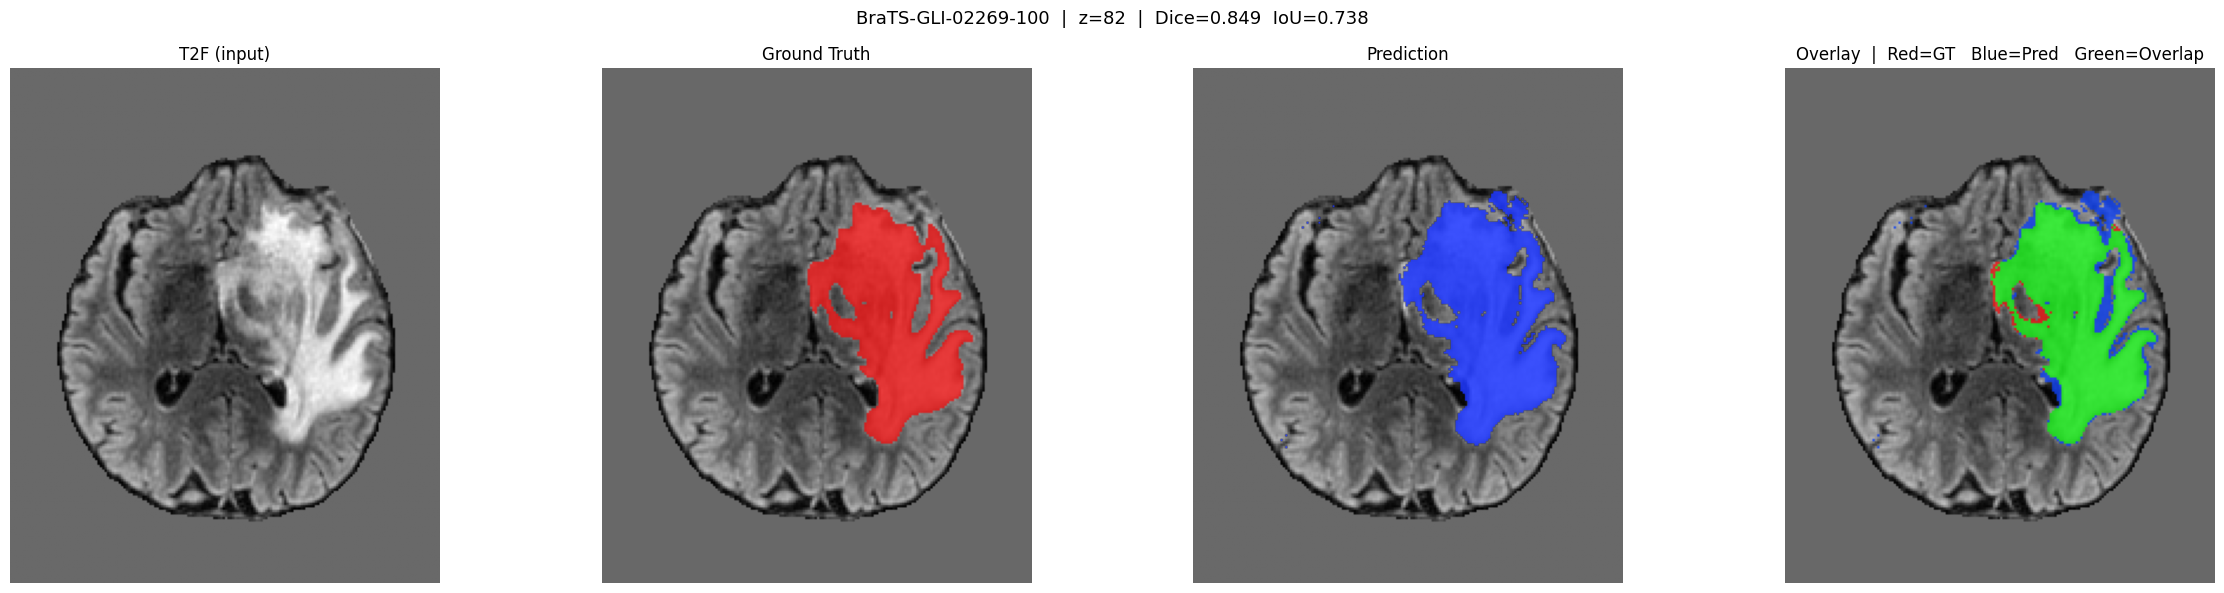


🎉 Done!  pred_bin and prob_vol available as numpy arrays.


In [11]:
# ============================================================
# STANDALONE INFERENCE CELL
# Run this independently — no need to re-run training code.
# Just set MODEL_PATH and PATIENT_PATH below.
# ============================================================

%matplotlib inline
import numpy as np
import nibabel as nib
import joblib
import os
import gc
import glob
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import uniform_filter, gaussian_filter, sobel as nd_sobel
from sklearn.metrics import f1_score, jaccard_score

# ── ✏️  SET THESE TWO PATHS ────────────────────────────────
MODEL_PATH   = r"D:\shashwat\models\xgb_brain_tumor_v6.pkl"
PATIENT_PATH = r"D:\shashwat\train\BraTS-GLI-02269-100"
THRESHOLD    = 0.50
# ──────────────────────────────────────────────────────────

MODALITIES = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX = 'seg'


# ── Helpers ────────────────────────────────────────────────

def _load_patient(patient_dir):
    patient_dir = Path(patient_dir)
    pid  = patient_dir.name
    data = {}
    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            if mod == SEG_SUFFIX:
                data[mod] = None
                continue
            raise FileNotFoundError(f"Missing modality '{mod}' in {patient_dir}")
        data[mod] = nib.load(matches[0]).get_fdata(dtype=np.float32)
    return pid, data


def _get_brain_mask(data):
    mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        mask |= (data[mod] > 0)
    return mask


def _zscore_normalize(volume, brain_mask):
    v   = volume.copy()
    roi = v[brain_mask]
    mu, sigma = roi.mean(), roi.std() + 1e-8
    v[brain_mask]  = (roi - mu) / sigma
    v[~brain_mask] = 0.0
    return v


def _preprocess(data ):
    brain_mask = _get_brain_mask(data)
    processed  = {}
    for mod in MODALITIES:
        processed[mod] = _zscore_normalize(data[mod], brain_mask)
    processed[SEG_SUFFIX] = data[SEG_SUFFIX]
    return processed, brain_mask


def _fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol ** 2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean ** 2, 0)).astype(np.float32)


def _extract_features(processed, brain_mask):
    cols = []

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))
        del vol

    for mod in MODALITIES:
        vol = processed[mod].astype(np.float32)
        add(vol.copy())
        add(uniform_filter(vol, size=3))
        add(_fast_local_std(vol, size=3))
        add(uniform_filter(vol, size=5))
        add(_fast_local_std(vol, size=5))
        add(uniform_filter(vol, size=9))
        add(_fast_local_std(vol, size=9))
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(gaussian_filter(vol, sigma=1.0).astype(np.float32))
        add(gaussian_filter(vol, sigma=2.0).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        add((g1 - g2).astype(np.float32))
        del g1, g2, vol
        gc.collect()

    shape = processed[MODALITIES[0]].shape
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); del xx
    add(yy); del yy
    add(zz); del zz
    gc.collect()

    eps = 1e-8
    add(np.clip(processed['t2w'] / (processed['t1c'] + eps), -10, 10).astype(np.float32))
    add(np.clip(processed['t2f'] / (processed['t1n'] + eps), -10, 10).astype(np.float32))
    add((processed['t2f'] - processed['t1c']).astype(np.float32))
    add((processed['t2w'] - processed['t1n']).astype(np.float32))
    add((processed['t1c'] - processed['t1n']).astype(np.float32))
    add((processed['t2f'] - processed['t2w']).astype(np.float32))

    X = np.column_stack(cols).astype(np.float32)
    del cols; gc.collect()
    return X


# ── Main inference ─────────────────────────────────────────

print("=" * 55)
print("  BraTS XGBoost v5 — Standalone Inference")
print("=" * 55)

# 1. Load model
print(f"\n📦 Loading model  : {MODEL_PATH}")
model = joblib.load(MODEL_PATH)
print(f"   ✅ Model loaded ({model.n_estimators} trees, depth {model.max_depth})")

# 2. Load & preprocess patient
print(f"\n🧠 Loading patient: {PATIENT_PATH}")
pid, data   = _load_patient(PATIENT_PATH)
proc, bmask = _preprocess(data)
print(f"   Patient ID   : {pid}")
print(f"   Volume shape : {proc[MODALITIES[0]].shape}  |  "
      f"Brain voxels: {bmask.sum():,}")

# 3. Extract features
print(f"\n⚙️  Extracting features...")
X = _extract_features(proc, bmask)
print(f"   Feature matrix : {X.shape}  ({X.nbytes / 1e6:.1f} MB)")

# 4. Predict in batches
BATCH  = 500_000
n      = X.shape[0]
y_prob = np.zeros(n, dtype=np.float32)

print(f"\n🔮 Predicting (threshold = {THRESHOLD})...")
for start in tqdm(range(0, n, BATCH), desc="Inference batches"):
    end = min(start + BATCH, n)
    y_prob[start:end] = model.predict_proba(X[start:end])[:, 1]

del X; gc.collect()

# 5. Reconstruct volumes
shape    = proc[MODALITIES[0]].shape
prob_vol = np.zeros(shape, dtype=np.float32)
pred_bin = np.zeros(shape, dtype=np.uint8)
prob_vol[bmask] = y_prob
pred_bin[bmask] = (y_prob >= THRESHOLD).astype(np.uint8)

print(f"\n📊 Prediction summary")
print(f"   Tumor voxels predicted : {pred_bin.sum():,}")
print(f"   Tumor volume fraction  : {pred_bin.mean()*100:.3f}%")

# 6. Metrics
has_gt = proc[SEG_SUFFIX] is not None
if has_gt:
    gt_bin = (proc[SEG_SUFFIX] > 0).astype(np.uint8)
    dice   = f1_score(gt_bin[bmask], pred_bin[bmask], zero_division=0)
    iou    = jaccard_score(gt_bin[bmask], pred_bin[bmask], zero_division=0)
    print(f"\n   Dice            : {dice:.4f}")
    print(f"   IoU             : {iou:.4f}")
    print(f"   GT tumor voxels : {gt_bin.sum():,}")
else:
    print("\n   (No seg file — skipping Dice/IoU)")
    gt_bin = None
    dice = iou = None

# 7. Visualise — shown inline, NOT saved to disk
best_z = int(np.argmax(gt_bin.sum(axis=(0, 1)))) if has_gt else \
         int(np.argmax(pred_bin.sum(axis=(0, 1))))

brain      = proc['t2f'][:, :, best_z]
brain_norm = (brain - brain.min()) / (brain.max() - brain.min() + 1e-8)
pred_sl    = pred_bin[:, :, best_z]

n_cols = 4 if has_gt else 2
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
title_str  = f"{pid}  |  z={best_z}"
if dice is not None:
    title_str += f"  |  Dice={dice:.3f}  IoU={iou:.3f}"
fig.suptitle(title_str, fontsize=13)

# Panel 1 — T2F input
axes[0].imshow(brain_norm.T, cmap='gray', origin='lower')
axes[0].set_title('T2F (input)'); axes[0].axis('off')

# Panel 2 — Ground Truth (separate, vivid red)
if has_gt:
    gt_sl  = gt_bin[:, :, best_z]
    rgb_gt = np.stack([brain_norm.T] * 3, axis=-1)
    ov_gt  = rgb_gt.copy()
    ov_gt[gt_sl.T > 0] = [0.9, 0.05, 0.05]
    axes[1].imshow(np.clip(rgb_gt * 0.2 + ov_gt * 0.8, 0, 1), origin='lower')
    axes[1].set_title('Ground Truth'); axes[1].axis('off')

# Panel 3 — Prediction overlay (vivid blue)
axes[2].imshow(brain_norm.T, cmap='gray', origin='lower')
pred_rgba = np.zeros((*pred_sl.T.shape, 4))
pred_rgba[pred_sl.T > 0] = [0.1, 0.2, 1.0, 0.85]
axes[2].imshow(pred_rgba, origin='lower')
axes[2].set_title('Prediction'); axes[2].axis('off')

# Panel 4 — Overlay: GT + Pred + Overlap
if has_gt:
    rgb   = np.stack([brain_norm.T] * 3, axis=-1)
    ov    = rgb.copy()
    ov[gt_sl.T   > 0]                    = [0.9, 0.05, 0.05]
    ov[pred_sl.T > 0]                    = [0.05, 0.25, 0.95]
    ov[(gt_sl.T > 0) & (pred_sl.T > 0)] = [0.05, 0.90, 0.05]
    axes[3].imshow(np.clip(rgb * 0.2 + ov * 0.8, 0, 1), origin='lower')
    axes[3].set_title('Overlay  |  Red=GT   Blue=Pred   Green=Overlap')
    axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"\n🎉 Done!  pred_bin and prob_vol available as numpy arrays.")

In [4]:
# ============================================================
# Evaluate XGBoost Brain Tumor Model on ALL Training Patients
# Loads saved model → runs full-volume prediction per patient
# → reports per-patient and average Dice scores
# ============================================================

import numpy as np
import nibabel as nib
import os
import gc
import glob
import pandas as pd
import joblib
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import uniform_filter, gaussian_filter, sobel as nd_sobel
from sklearn.metrics import f1_score, jaccard_score

# ── Paths — update these to match your setup ──────────────
BASE_DIR   = r"D:\shashwat"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
MODEL_PATH = os.path.join(BASE_DIR, "models", "xgb_brain_tumor_v7.pkl")

MODALITIES = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX = 'seg'

# ── Settings ───────────────────────────────────────────────
BEST_THRESHOLD = 0.6    # same threshold used during testing
BATCH_SIZE     = 500_000  # predict in batches to avoid RAM spike


# ==============================================================
# Helper functions — identical to your training code
# ==============================================================

def get_patient_dirs(split_dir):
    return sorted([d for d in Path(split_dir).iterdir() if d.is_dir()])


def load_patient(patient_dir):
    patient_dir = Path(patient_dir)
    pid  = patient_dir.name
    data = {}
    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            raise FileNotFoundError(f"Missing {mod} for {pid}")
        data[mod] = nib.load(matches[0]).get_fdata(dtype=np.float32)
    return pid, data


def get_brain_mask(data):
    mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        mask |= (data[mod] > 0)
    return mask


def zscore_normalize(volume, brain_mask):
    v   = volume.copy()
    roi = v[brain_mask]
    mu, sigma = roi.mean(), roi.std() + 1e-8
    v[brain_mask]  = (roi - mu) / sigma
    v[~brain_mask] = 0.0
    return v


def preprocess_patient(data):
    brain_mask = get_brain_mask(data)
    processed  = {}
    for mod in MODALITIES:
        processed[mod] = zscore_normalize(data[mod], brain_mask)
    processed[SEG_SUFFIX] = data[SEG_SUFFIX]
    return processed, brain_mask


def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)


def extract_features(processed, brain_mask):
    """Exact same 53-feature extraction as training — must not change."""
    cols = []

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))
        del vol

    for mod in MODALITIES:
        vol = processed[mod].astype(np.float32)
        add(vol.copy())
        add(uniform_filter(vol, size=3))
        add(fast_local_std(vol, size=3))
        add(uniform_filter(vol, size=5))
        add(fast_local_std(vol, size=5))
        add(uniform_filter(vol, size=9))
        add(fast_local_std(vol, size=9))
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(gaussian_filter(vol, sigma=1.0).astype(np.float32))
        add(gaussian_filter(vol, sigma=2.0).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        add((g1 - g2).astype(np.float32))
        del g1, g2, vol
        gc.collect()

    shape = processed[MODALITIES[0]].shape
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); del xx
    add(yy); del yy
    add(zz); del zz
    gc.collect()

    eps = 1e-8
    add(np.clip(processed['t2w'] / (processed['t1c'] + eps), -10, 10).astype(np.float32))
    add(np.clip(processed['t2f'] / (processed['t1n'] + eps), -10, 10).astype(np.float32))
    add((processed['t2f'] - processed['t1c']).astype(np.float32))
    add((processed['t2w'] - processed['t1n']).astype(np.float32))
    add((processed['t1c'] - processed['t1n']).astype(np.float32))
    add((processed['t2f'] - processed['t2w']).astype(np.float32))

    X = np.column_stack(cols).astype(np.float32)
    del cols; gc.collect()

    y = (processed[SEG_SUFFIX][brain_mask] > 0).astype(np.uint8)
    return X, y


# ==============================================================
# Main evaluation loop
# ==============================================================

def evaluate_on_train(model, train_patients, threshold):
    print(f"\n{'='*55}")
    print(f"  Evaluating on {len(train_patients)} TRAINING patients")
    print(f"  Model   : {MODEL_PATH}")
    print(f"  Threshold: {threshold}")
    print(f"{'='*55}\n")

    results  = []
    failed   = []

    for pdir in tqdm(train_patients, desc="Train eval"):
        pid = Path(pdir).name
        try:
            # Step 1 — load MRI + seg
            pid, data   = load_patient(pdir)
            proc, bmask = preprocess_patient(data)
            del data; gc.collect()

            # Step 2 — extract features from 4 modalities
            X, y_true = extract_features(proc, bmask)
            del proc, bmask; gc.collect()

            # Step 3 — predict in batches
            y_prob = np.zeros(len(X), dtype=np.float32)
            for s in range(0, len(X), BATCH_SIZE):
                e = min(s + BATCH_SIZE, len(X))
                y_prob[s:e] = model.predict_proba(X[s:e])[:, 1]
            del X; gc.collect()

            # Step 4 — apply threshold
            pred = (y_prob >= threshold).astype(np.uint8)
            del y_prob; gc.collect()

            # Step 5 — compute metrics
            gt_vox   = int((y_true == 1).sum())
            pred_vox = int(pred.sum())

            dice = f1_score(y_true, pred, zero_division=0)
            iou  = jaccard_score(y_true, pred, zero_division=0)

            results.append({
                'patient'  : pid,
                'dice'     : dice,
                'iou'      : iou,
                'gt_vox'   : gt_vox,
                'pred_vox' : pred_vox,
                'status'   : 'no_tumor' if gt_vox == 0 else 'ok'
            })

            del y_true, pred; gc.collect()

        except Exception as e:
            failed.append(pid)
            tqdm.write(f"⚠️  {pid}: {e}")

    # ── Results summary ────────────────────────────────────
    df    = pd.DataFrame(results)
    dices = df['dice'].values

    # Separate patients with actual tumors from edge cases
    df_tumor    = df[df['status'] == 'ok']
    df_notumor  = df[df['status'] == 'no_tumor']

    print(f"\n{'='*55}")
    print(f"  TRAINING SET — Full Results ({len(df)} patients)")
    print(f"{'='*55}")
    print(f"\n  ── All patients ──────────────────────────")
    print(f"  Mean   Dice : {dices.mean():.4f}")
    print(f"  Std    Dice : {dices.std():.4f}")
    print(f"  Median Dice : {np.median(dices):.4f}")
    print(f"  Min    Dice : {dices.min():.4f}  "
          f"({df.loc[df.dice.idxmin(), 'patient']})")
    print(f"  Max    Dice : {dices.max():.4f}  "
          f"({df.loc[df.dice.idxmax(), 'patient']})")
    print(f"  Dice ≥ 0.9  : {(dices >= 0.9).sum()} / {len(dices)}")
    print(f"  Dice ≥ 0.7  : {(dices >= 0.7).sum()} / {len(dices)}")
    print(f"  Dice ≥ 0.5  : {(dices >= 0.5).sum()} / {len(dices)}")
    print(f"  Dice < 0.5  : {(dices < 0.5).sum()} / {len(dices)}")
    print(f"  Mean   IoU  : {df['iou'].mean():.4f}")

    if len(df_tumor) > 0:
        t_dices = df_tumor['dice'].values
        print(f"\n  ── Tumor patients only ({len(df_tumor)}) ──────────")
        print(f"  Mean   Dice : {t_dices.mean():.4f}")
        print(f"  Std    Dice : {t_dices.std():.4f}")
        print(f"  Median Dice : {np.median(t_dices):.4f}")

    if len(df_notumor) > 0:
        print(f"\n  ── No-tumor patients : {len(df_notumor)} ──────────")
        print(f"  (Dice=0 by definition — seg is all zeros)")
        print(f"  Patients: {df_notumor['patient'].tolist()}")

    if failed:
        print(f"\n  ⚠️  Failed to process: {failed}")

    print(f"\n{'='*55}")

    # ── Comparison with test results ──────────────────────
    print(f"\n  ── Train vs Test comparison ──────────────")
    print(f"  {'Metric':<20} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*42}")
    print(f"  {'Mean Dice':<20} {dices.mean():>10.4f} {'0.7320':>10}")
    print(f"  {'Median Dice':<20} {np.median(dices):>10.4f} {'0.7901':>10}")
    print(f"  {'Mean IoU':<20} {df['iou'].mean():>10.4f} {'0.6045':>10}")
    print(f"  {'Dice ≥ 0.7':<20} {(dices >= 0.7).sum():>10} {'94':>10}")
    print(f"\n  Gap (Train - Test) : "
          f"{dices.mean() - 0.7320:+.4f}")
    print(f"\n  If Train Dice >> Test Dice → overfitting")
    print(f"  If Train Dice ≈  Test Dice → good generalization")
    print(f"{'='*55}\n")

    # ── Save detailed results ─────────────────────────────
    save_path = os.path.join(BASE_DIR, "models", "train_eval_results.csv")
    df.to_csv(save_path, index=False)
    print(f"  📊 Per-patient results saved → {save_path}")

    return df


# ==============================================================
# MAIN
# ==============================================================

if __name__ == "__main__":

    # ── Load saved model ───────────────────────────────────
    print(f"📦 Loading model from {MODEL_PATH}...")
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"Model not found at {MODEL_PATH}\n"
            f"Make sure you have run the training script first."
        )
    model = joblib.load(MODEL_PATH)
    print(f"✅ Model loaded successfully")

    # ── Get training patient directories ──────────────────
    train_patients = get_patient_dirs(TRAIN_DIR)
    print(f"📁 Found {len(train_patients)} training patients in {TRAIN_DIR}")

    # ── Run evaluation ─────────────────────────────────────
    df_results = evaluate_on_train(model, train_patients, BEST_THRESHOLD)

    print("🎉 Done!")

📦 Loading model from D:\shashwat\models\xgb_brain_tumor_v7.pkl...
✅ Model loaded successfully
📁 Found 1012 training patients in D:\shashwat\train

  Evaluating on 1012 TRAINING patients
  Model   : D:\shashwat\models\xgb_brain_tumor_v7.pkl
  Threshold: 0.6



Train eval: 100%|██████████| 1012/1012 [2:21:49<00:00,  8.41s/it] 


  TRAINING SET — Full Results (1012 patients)

  ── All patients ──────────────────────────
  Mean   Dice : 0.7494
  Std    Dice : 0.1671
  Median Dice : 0.7943
  Min    Dice : 0.0002  (BraTS-GLI-02767-101)
  Max    Dice : 0.9700  (BraTS-GLI-02116-101)
  Dice ≥ 0.9  : 123 / 1012
  Dice ≥ 0.7  : 750 / 1012
  Dice ≥ 0.5  : 918 / 1012
  Dice < 0.5  : 94 / 1012
  Mean   IoU  : 0.6237

  ── Tumor patients only (1012) ──────────
  Mean   Dice : 0.7494
  Std    Dice : 0.1671
  Median Dice : 0.7943


  ── Train vs Test comparison ──────────────
  Metric                    Train       Test
  ------------------------------------------
  Mean Dice                0.7494     0.7320
  Median Dice              0.7943     0.7901
  Mean IoU                 0.6237     0.6045
  Dice ≥ 0.7                  750         94

  Gap (Train - Test) : +0.0174

  If Train Dice >> Test Dice → overfitting
  If Train Dice ≈  Test Dice → good generalization

  📊 Per-patient results saved → D:\shashwat\models\train_e